In [1]:
import pathlib
import textwrap

import pandas as pd
from image_analysis_3D.file_utils.notebook_init_utils import init_notebook
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from pandas.plotting import table

root_dir, in_notebook = init_notebook()

In [2]:
sc_profiles_path = pathlib.Path(
    root_dir,
    "data/all_patient_profiles/0.normalized_profiles/sc_norm_norm_profile.parquet",
).resolve(strict=True)
organoid_profiles_path = pathlib.Path(
    root_dir,
    "data/all_patient_profiles/0.normalized_profiles/organoid_norm_norm_profile.parquet",
).resolve(strict=True)

patient_extra_metadata_path = pathlib.Path(
    root_dir,
    "config/patient_extra_metadata/patient_drug_screen_theoretical_counts_and_tumor_type"
    ".tsv",
).resolve(strict=True)
table1_results_path = pathlib.Path(
    root_dir,
    "figures/table1_patients_and_counts/results/table1_patients_and_counts_results.tsv",
).resolve()
table1_results_path.parent.mkdir(parents=True, exist_ok=True)

In [3]:
sc_df = pd.read_parquet(sc_profiles_path)
organoid_df = pd.read_parquet(organoid_profiles_path)

patient_extra_metadata_df = pd.read_csv(patient_extra_metadata_path, sep="\t")

In [4]:
# get the unique combinations of Metadata_Biology_PatientTumor and Metadata_Experiment_Treatment
compounds_counts = (
    organoid_df.groupby(
        ["Metadata_Biology_PatientTumor", "Metadata_Experiment_Treatment"]
    )
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "count"})
    .drop(columns="count")
    .groupby(["Metadata_Biology_PatientTumor"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_compounds"})
)

In [5]:
# get the unique combinations of Metadata_Biology_PatientTumor, Metadata_Experiment_Treatment, and Metadata_Experiment_Dose
treatments_counts = (
    organoid_df.groupby(
        [
            "Metadata_Biology_PatientTumor",
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Dose",
        ]
    )
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "count"})
    .drop(columns="count")
    .groupby(["Metadata_Biology_PatientTumor"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_treatments"})
)

In [6]:
# get the unique combinations of Metadata_Biology_PatientTumor and Metadata_Experiment_Well
well_counts = (
    sc_df.groupby(["Metadata_Biology_PatientTumor", "Metadata_Experiment_Well"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "count"})
    .drop(columns="count")
    .groupby(["Metadata_Biology_PatientTumor"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_wells"})
)

In [7]:
well_fov_counts = (
    sc_df.groupby(
        [
            "Metadata_Biology_PatientTumor",
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Well",
            "Metadata_Experiment_WellFOV",
        ]
    )
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "count"})
    .drop(columns="count")
    .groupby(["Metadata_Biology_PatientTumor"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_well_fovs"})
)

In [8]:
organoid_counts = (
    sc_df.groupby(
        [
            "Metadata_Biology_PatientTumor",
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Well",
            "Metadata_Experiment_WellFOV",
            "Metadata_Object_ParentOrganoid",
        ]
    )
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "count"})
    .drop(columns="count")
    .loc[sc_df["Metadata_Object_ParentOrganoid"] != -1]
    .groupby(["Metadata_Biology_PatientTumor"])
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_organoids"})
)

In [9]:
sc_df.groupby(
    [
        "Metadata_Biology_PatientTumor",
        "Metadata_Experiment_Treatment",
        "Metadata_Experiment_Well",
        "Metadata_Experiment_WellFOV",
    ]
).size().to_frame().reset_index().rename(columns={0: "count"})
# sum the count at the Metadata_Biology_PatientTumor level
sc_df.groupby(
    [
        "Metadata_Biology_PatientTumor",
        "Metadata_Experiment_Treatment",
        "Metadata_Experiment_Well",
        "Metadata_Experiment_WellFOV",
    ]
).size().to_frame().reset_index().rename(columns={0: "count"}).groupby(
    ["Metadata_Biology_PatientTumor"]
).sum()

single_cell_counts = (
    sc_df.groupby(
        [
            "Metadata_Biology_PatientTumor",
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Well",
            "Metadata_Experiment_WellFOV",
        ]
    )
    .size()
    .to_frame()
    .reset_index()
    .rename(columns={0: "number_of_single_cells"})
    .groupby(["Metadata_Biology_PatientTumor"])
    .sum()
    .drop(
        columns=[
            "Metadata_Experiment_Treatment",
            "Metadata_Experiment_Well",
            "Metadata_Experiment_WellFOV",
        ]
    )
    .reset_index()
)

In [10]:
table1 = pd.merge(
    pd.merge(
        pd.merge(
            pd.merge(
                pd.merge(
                    compounds_counts,
                    treatments_counts,
                    on="Metadata_Biology_PatientTumor",
                ),
                well_counts,
                on="Metadata_Biology_PatientTumor",
            ),
            well_fov_counts,
            on="Metadata_Biology_PatientTumor",
        ),
        organoid_counts,
        on="Metadata_Biology_PatientTumor",
    ),
    single_cell_counts,
    on="Metadata_Biology_PatientTumor",
)

In [11]:
table1 = pd.merge(
    table1,
    patient_extra_metadata_df,
    left_on="Metadata_Biology_PatientTumor",
    right_on="patient",
    how="left",
).drop(columns=["patient"])
table1.to_csv(table1_results_path, index=False, sep="\t")

In [12]:
tumor_type = table1.pop("Tumor_type")
table1.insert(1, "Tumor_type", tumor_type)
table1.rename(
    columns={
        "Metadata_Biology_PatientTumor": "Patient Tumor ",
        "Tumor_type": "Tumor type ",
        "number_of_compounds": "Compound Count",
        "number_of_treatments": "Treatment Count",
        "number_of_wells": "Well Count",
        "number_of_well_fovs": "Well FOV Count",
        "number_of_organoids": "Organoid Count",
        "number_of_single_cells": "Single Cell Count",
        "theoretical_number_of_compounds": "Theoretical Compound Count",
        "theoretical_number_of_treatments": "Theoretical Treatment Count",
        "theoretical_number_of_well_fovs": "Theoretical Well FOV Count",
    },
    inplace=True,
)

In [13]:
# convert the table to a markdown table
table1_md = table1.to_markdown(index=False, tablefmt="pipe")

In [14]:
# Display the table nicely formatted

# Display as formatted markdown
print("Rendered Table:")
display(Markdown(table1_md))

Rendered Table:


| Patient Tumor    | Tumor type                                       |   Compound Count |   Treatment Count |   Well Count |   Well FOV Count |   Organoid Count |   Single Cell Count |   Theoretical Compound Count |   Theoretical Treatment Count |   Theoretical Well FOV Count |
|:-----------------|:-------------------------------------------------|-----------------:|------------------:|-------------:|-----------------:|-----------------:|--------------------:|-----------------------------:|------------------------------:|-----------------------------:|
| NF0014_T1        | Neurofibroma (subcutaneous)                      |               17 |                21 |           50 |               95 |              191 |                2132 |                           17 |                            21 |                          104 |
| NF0014_T2        | Plexiform Neurofibroma                           |               17 |                21 |           50 |              347 |              870 |                2939 |                           17 |                            21 |                          350 |
| NF0016_T1        | Neurofibroma, diffuse and plexiform              |               16 |                20 |           46 |              117 |              257 |                 981 |                           17 |                            21 |                          122 |
| NF0018_T6        | Cutaneous Neurofibroma                           |               17 |                21 |           50 |              152 |              271 |                1442 |                           17 |                            21 |                          160 |
| NF0021_T1        | Cutaneous Neurofibroma                           |               17 |                21 |           50 |              346 |              820 |                5027 |                           17 |                            21 |                          348 |
| NF0030_T1        | Myopericytoma                                    |               17 |                21 |           50 |              204 |              696 |                3755 |                           17 |                            21 |                          207 |
| NF0035_T1        | Cutaneous Neurofibroma                           |               17 |                21 |           50 |              347 |              621 |                4780 |                           22 |                            21 |                          349 |
| NF0037_T1        | Cutaneous Neurofibroma                           |               22 |                26 |           60 |              416 |              793 |                7489 |                           22 |                            26 |                          420 |
| NF0037_T1_CQ1    | Cutaneous Neurofibroma                           |               22 |                26 |           60 |              660 |             1067 |               13055 |                           22 |                            26 |                          693 |
| NF0040_T1        | Schwannoma, with degeneration                    |               22 |                26 |           60 |              411 |              588 |                5006 |                           22 |                            25 |                          420 |
| NF0055_T1        | Plexiform Neurofibroma                           |               21 |                25 |           53 |              341 |              731 |                4325 |                           21 |                            21 |                          420 |
| SARCO219_T2      | MPNST in association with plexiform neurofibroma |               17 |                21 |           50 |              199 |             3086 |               12591 |                           17 |                            21 |                          199 |
| SARCO361_T1      | Sarcoma                                          |               17 |                21 |           50 |              349 |             1505 |                4029 |                           17 |                            21 |                          350 |

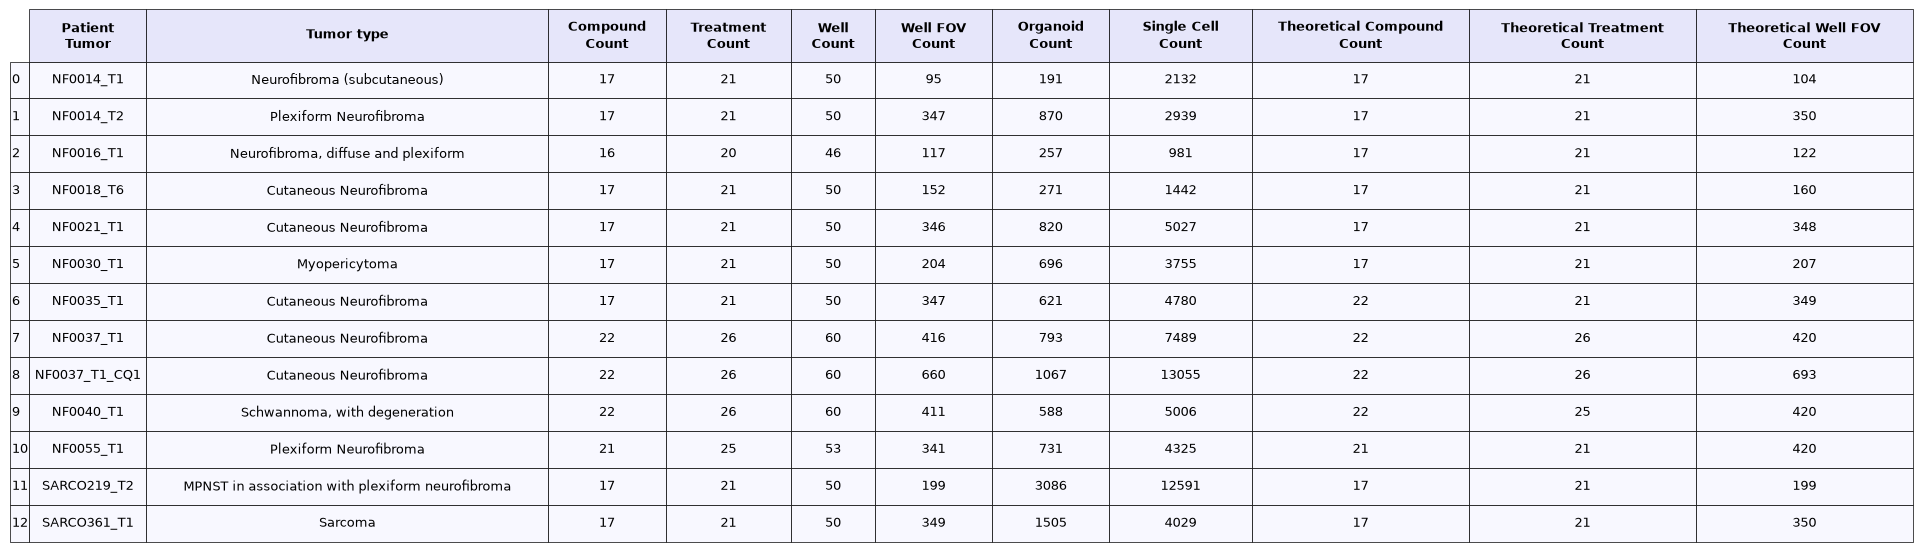

In [15]:
n_columns = table1.shape[1]


# --- Estimate a reasonable character-width budget per column ---
def col_char_width(col):
    header_len = len(str(col))
    value_len = table1[col].astype(str).map(len).max()
    return max(header_len, value_len, 6)


raw_widths = [col_char_width(c) for c in table1.columns]
total = sum(raw_widths)
col_widths = [w / total for w in raw_widths]

# --- Pre-wrap header text manually (don't rely on matplotlib's wrap=True) ---
# Wrap width in characters, scaled to how wide the column actually is.
wrapped_columns = []
for col, w in zip(table1.columns, raw_widths):
    wrap_at = max(int(w * 0.9), 8)  # characters per line, floor of 8
    wrapped = "\n".join(textwrap.wrap(str(col), width=wrap_at))
    wrapped_columns.append(wrapped)

table1_display = table1.copy()
table1_display.columns = wrapped_columns

# --- Figure sizing ---
fig_width = max(15, n_columns * 1.7)
fig, ax = plt.subplots(figsize=(fig_width, 4))
ax.axis("off")

tbl = table(
    ax,
    table1_display,
    loc="center",
    cellLoc="center",
    colWidths=col_widths,
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.3, 2.6)

# Row 0 in pandas.plotting.table is the header when index is shown.
n_header_lines = max(wc.count("\n") + 1 for wc in wrapped_columns)

for (i, j), cell in tbl.get_celld().items():
    cell.set_edgecolor("black")
    cell.set_linewidth(0.5)
    cell.set_text_props(wrap=False)  # we already hard-wrapped the text ourselves

    if i == 0:
        cell.set_facecolor("#E6E6FA")
        cell.set_text_props(weight="bold", wrap=False, linespacing=1.3)
        cell.set_height(0.06 * n_header_lines + 0.05)
    else:
        cell.set_facecolor("#F8F8FF")
        cell.set_height(0.12)

output_path = pathlib.Path(
    root_dir,
    "figures/table1_patients_and_counts/figures/table1_patients_and_counts.svg",
)
output_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path, format="svg", bbox_inches="tight", dpi=600)
plt.show()